# Worked example: MK8000 vs DWM1001C

Raw measurements -> position errors -> Table III of the paper, using `uwb.py`.

* Test area: L-shaped garage, 5 anchors, static tag at 1.00 m height.
* Each test point has **30 ranging cycles** per system (two-way ranging).
* `data/` holds **68 test points**: 64 inside the anchor polygon plus 4 exterior control points (IDs 1, 26, 112, 129).
  Point 1 of the DWM1001C was measured six times; all 180 cycles are pooled.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

import uwb, plot_fig1

pd.options.display.float_format = "{:.1f}".format
COLORS = {"DWM1001C": "#2f6b3d", "MK8000": "#aa3333"}

## 1. Data

In [2]:
rows = []
for system in uwb.FILES:
    df = uwb.load(system)
    valid = df[[f"r_AN{i}" for i in range(5)]].notna()
    cycles = df.groupby("point_id").size()
    rows.append({"system": system, "rows": len(df), "points": df.point_id.nunique(),
                 "cycles / point": str(cycles.min()) if cycles.min() == cycles.max() else f"{cycles.min()} (point 1: {cycles.max()})",
                 **{f"valid ranges {a}": f"{valid[f'r_AN{i}'].mean():.0%}" for i, a in enumerate(uwb.ANCHORS)}})
pd.DataFrame(rows).set_index("system").T

system,DWM1001C,MK8000
rows,2190,2040
points,68,68
cycles / point,30 (point 1: 180),30
valid ranges A0,74%,99%
valid ranges A1,81%,98%
valid ranges A2,100%,100%
valid ranges A3,99%,98%
valid ranges A4,31%,97%


MK8000 interrogates every anchor explicitly and reports SNR/RSSI per anchor. The DWM1001C (PANS firmware) keeps at most
four anchors per cycle and reports only a position quality factor, so far anchors (A4, A0) are often missing.

## 2. Test area (paper Fig. 1)

68 test points (64 inside the hull) -> figures/fig1_test_area.png


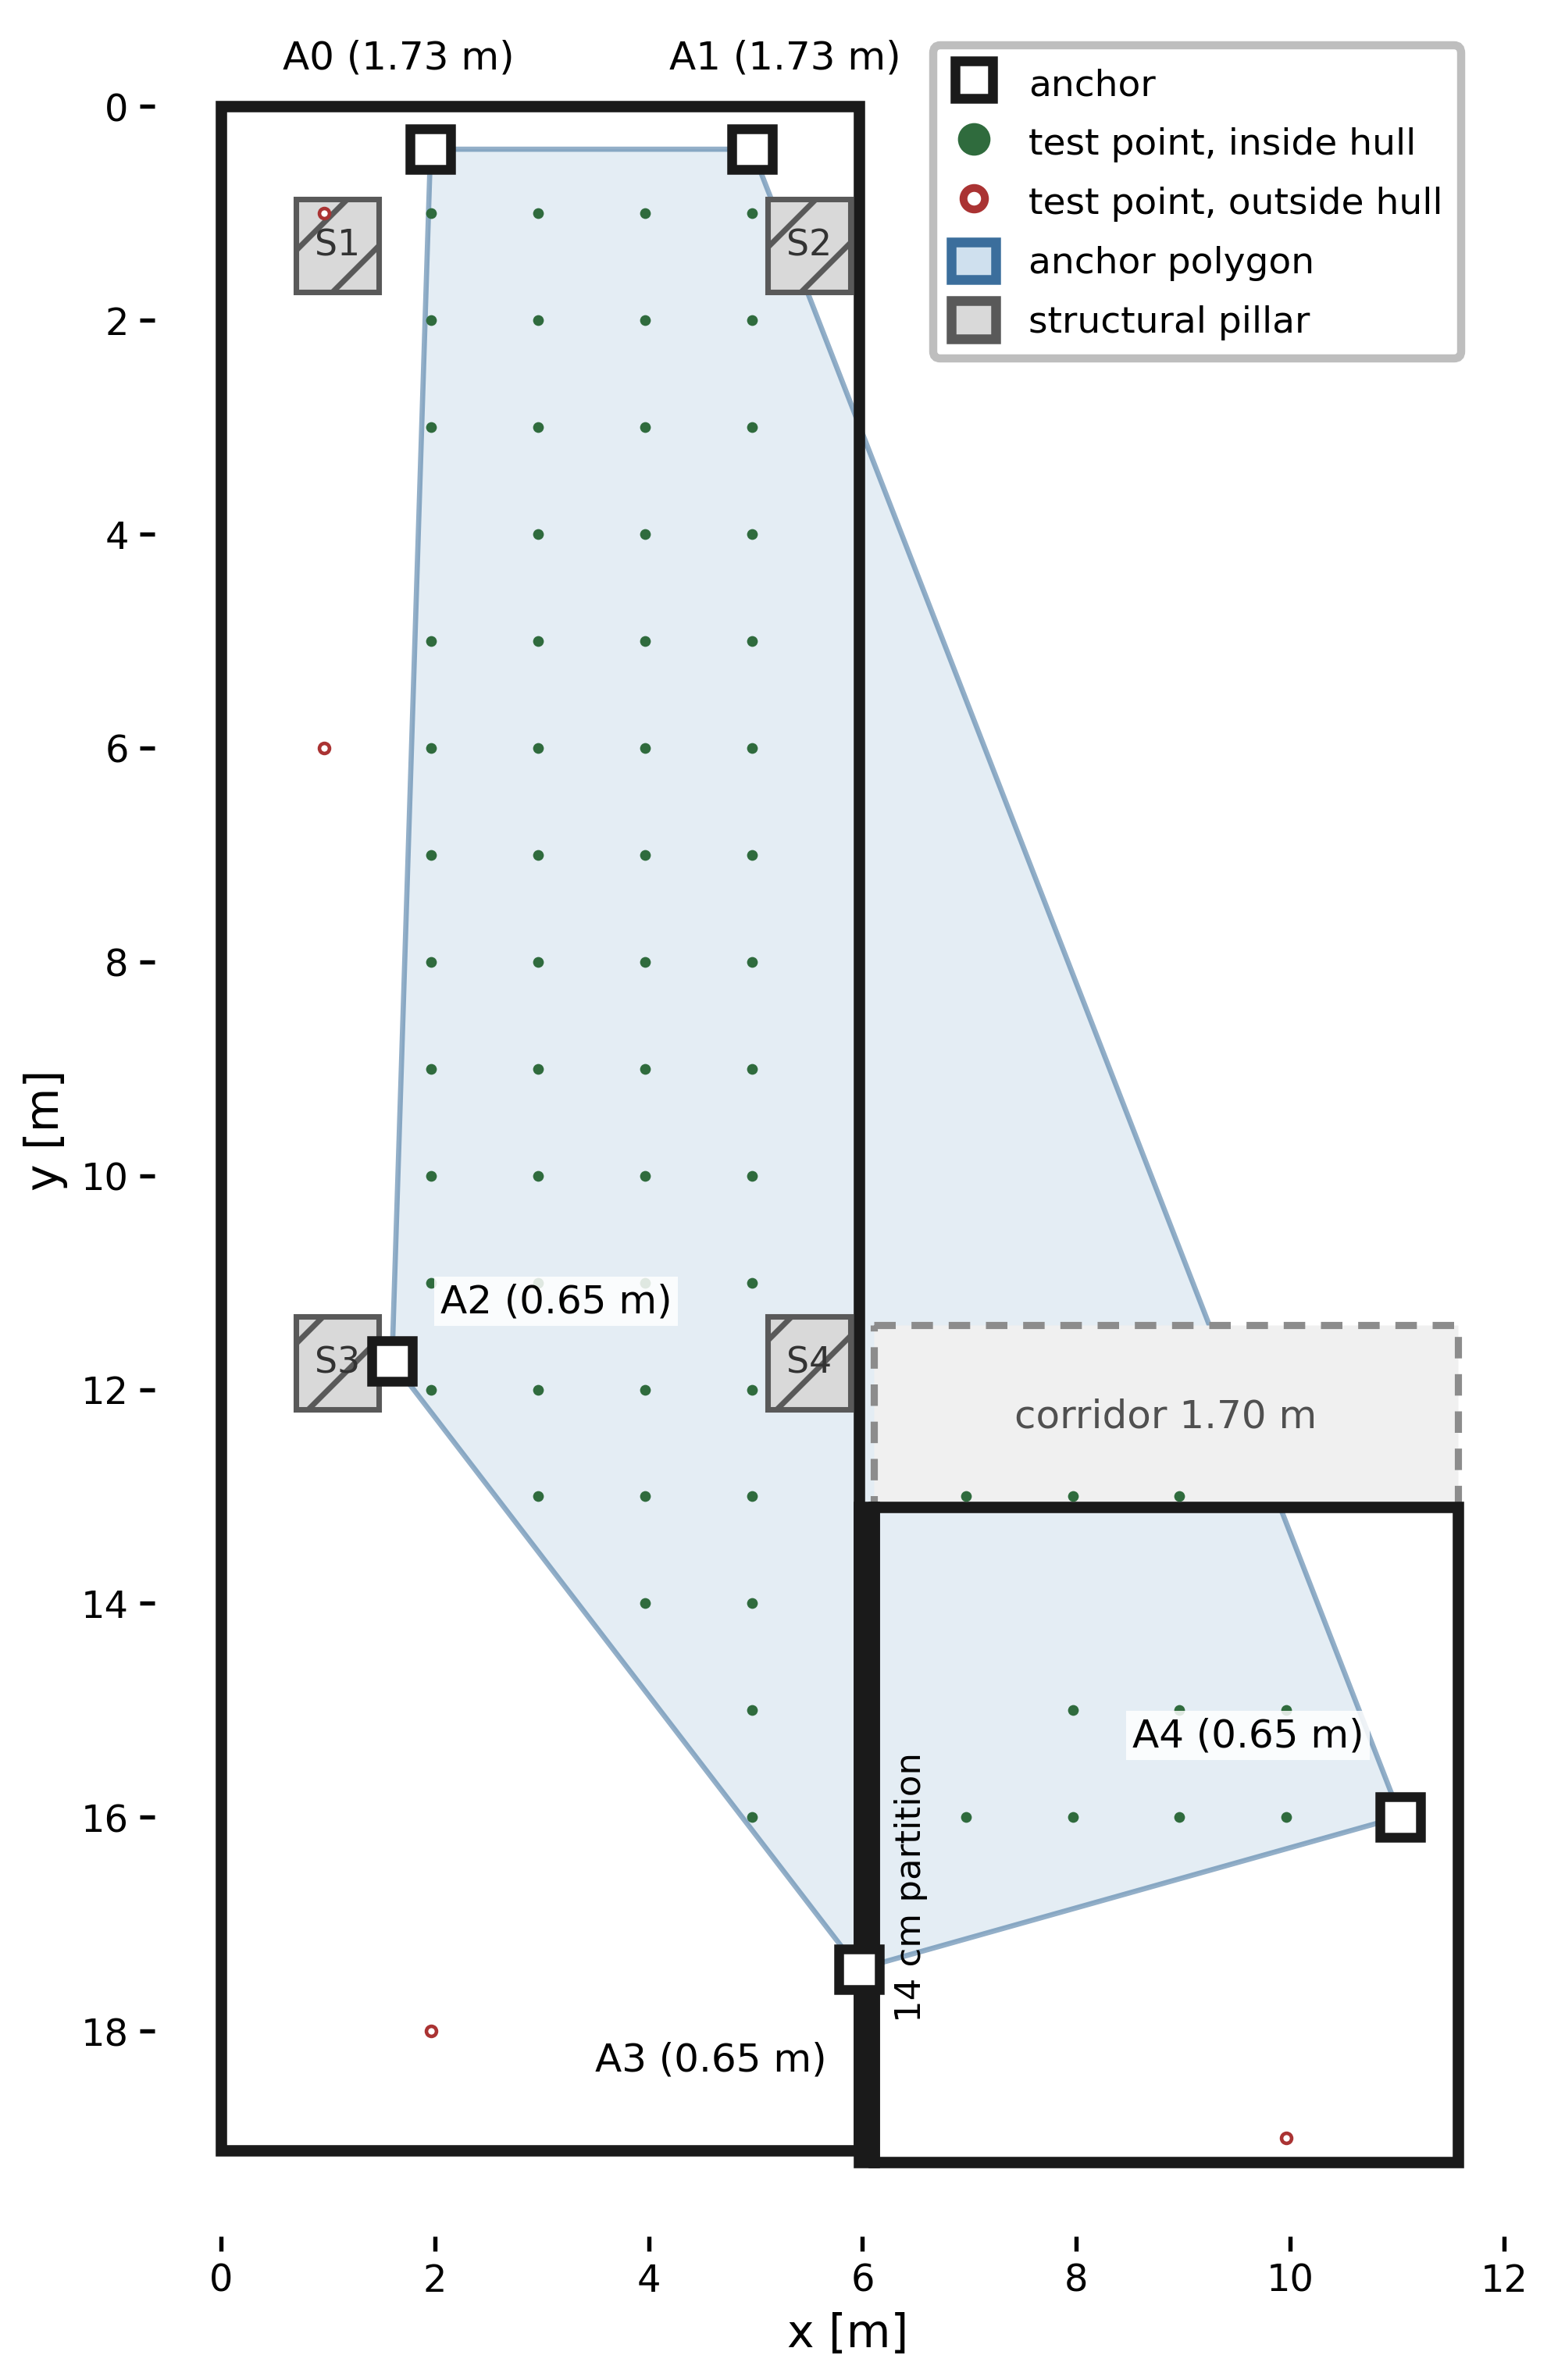

In [3]:
plot_fig1.draw()
Image(filename="figures/fig1_test_area.png", width=460)

## 3. Pipeline on one test point

For every point: project the slant ranges to the horizontal plane, average the 30 cycles, choose a reference anchor
(best quality; MK8000: mean SNR, DWM1001C: lowest spread of the repeated ranges), keep at most four anchors, then
trilaterate.

In [4]:
point = 40
for system in uwb.FILES:
    g = uwb.load(system).query("point_id == @point")
    h = g[[f"h_{a}" for a in uwb.ANCHORS]].mean()
    q = uwb.quality(system, g)
    ref, active = uwb.select_anchors({a: h[f"h_{a}"] for a in uwb.ANCHORS if not np.isnan(h[f"h_{a}"])}, q)
    print(f"{system}: true position ({g.gt_x.iloc[0]:.3f}, {g.gt_y.iloc[0]:.3f}) m, reference {ref}, anchors {active}")
    for est in uwb.ESTIMATORS:
        (x, y), used = uwb.locate(system, g, est)
        err = 100 * np.hypot(x - g.gt_x.iloc[0], y - g.gt_y.iloc[0])
        print(f"   {est:6s} -> ({x:6.2f}, {y:6.2f}) m   error {err:6.1f} cm   anchors used {[a for a in used]}")

DWM1001C: true position (4.965, 8.000) m, reference A2, anchors ['A0', 'A1', 'A2', 'A3']
   OLS    -> (  2.53,   7.68) m   error  246.0 cm   anchors used ['A0', 'A1', 'A2', 'A3']
   WLS    -> (  3.78,   7.63) m   error  124.0 cm   anchors used ['A0', 'A1', 'A2', 'A3']


   RANSAC -> (  6.67,   6.92) m   error  201.8 cm   anchors used ['A0', 'A1', 'A3']
MK8000: true position (4.965, 8.000) m, reference A2, anchors ['A0', 'A1', 'A2', 'A3']
   OLS    -> (  4.01,   7.73) m   error   99.4 cm   anchors used ['A0', 'A1', 'A2', 'A3']
   WLS    -> (  4.98,   7.75) m   error   25.3 cm   anchors used ['A0', 'A1', 'A2', 'A3']
   RANSAC -> (  5.04,   7.77) m   error   24.6 cm   anchors used ['A0', 'A1', 'A2', 'A3']


## 4. Results: positioning error (paper Table III)

Horizontal error in cm: mean, sample standard deviation and 95th percentile over the 64 interior points (`_64`), and
the mean over all 68 points (`mean_68`). `match` is true when mean_64, p95_64 and mean_68 are identical to the values
printed in the paper after rounding to 0.1 cm.

In [5]:
errors = pd.concat([uwb.run(s) for s in uwb.FILES])
table = uwb.summarize(errors)
paper = pd.DataFrame([uwb.PAPER_TABLE_III[(r.system, r.estimator)] for r in table.itertuples()],
                     columns=["paper_mean_64", "paper_p95_64", "paper_mean_68"])
table = pd.concat([table, paper], axis=1)
table["match"] = ((table.mean_64 == table.paper_mean_64) & (table.p95_64 == table.paper_p95_64)
                  & (table.mean_68 == table.paper_mean_68))
assert table.match.all()
table

,system,estimator,mean_64,std_64,p95_64,mean_68,paper_mean_64,paper_p95_64,paper_mean_68,match
0,DWM1001C,OLS,105.0,83.6,254.1,104.1,105.0,254.1,104.1,True
1,DWM1001C,WLS,69.4,43.3,148.7,70.2,69.4,148.7,70.2,True
2,DWM1001C,RANSAC,61.2,39.6,137.3,63.0,61.2,137.3,63.0,True
3,MK8000,OLS,247.7,208.9,587.0,249.0,247.7,587.0,249.0,True
4,MK8000,WLS,159.7,175.5,467.9,164.6,159.7,467.9,164.6,True
5,MK8000,RANSAC,203.7,208.4,681.8,200.1,203.7,681.8,200.1,True


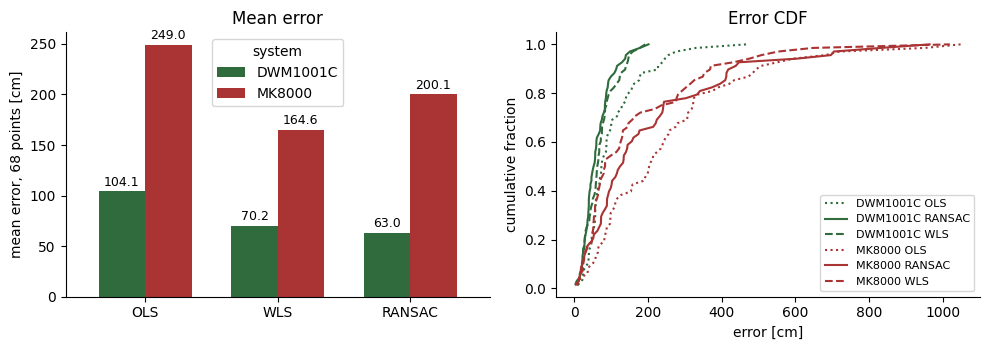

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

ax = axes[0]
pivot = table.pivot(index="estimator", columns="system", values="mean_68").loc[list(uwb.ESTIMATORS)]
pivot[list(COLORS)].plot.bar(ax=ax, rot=0, color=list(COLORS.values()), width=0.7)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", padding=2, fontsize=9)
ax.set_ylabel("mean error, 68 points [cm]"); ax.set_xlabel(""); ax.set_title("Mean error")

ax = axes[1]
for (system, est), g in errors.groupby(["system", "estimator"]):
    e = np.sort(g.error_cm)
    ax.plot(e, np.arange(1, len(e) + 1) / len(e), color=COLORS[system],
            ls={"OLS": ":", "WLS": "--", "RANSAC": "-"}[est], label=f"{system} {est}")
ax.set_xlabel("error [cm]"); ax.set_ylabel("cumulative fraction"); ax.set_title("Error CDF"); ax.legend(fontsize=8)
for a in axes:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

The best estimator differs between platforms: **RANSAC** for DWM1001C (a few grossly wrong ranges are rejected) and
**per-point WLS** for MK8000 (NLOS bias is spread over several anchors, so down-weighting works better than rejecting a
single anchor).

## 5. Where the errors are (best estimator per system)

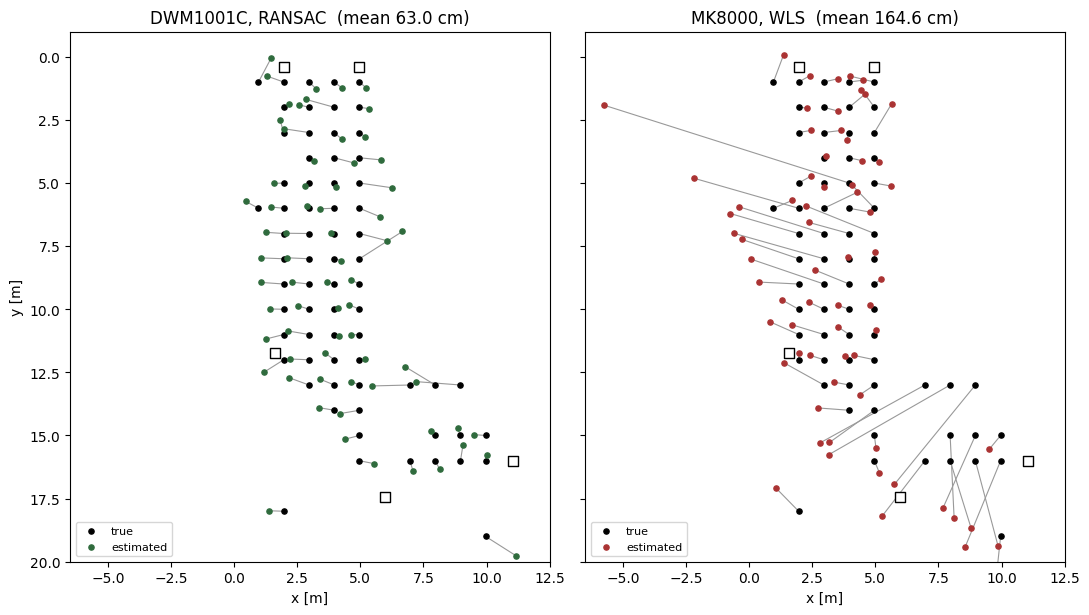

In [7]:
best = {"DWM1001C": "RANSAC", "MK8000": "WLS"}
fig, axes = plt.subplots(1, 2, figsize=(11, 7.2), sharex=True, sharey=True)
for ax, (system, est) in zip(axes, best.items()):
    g = errors[(errors.system == system) & (errors.estimator == est)]
    ax.plot([g.gt_x, g.est_x], [g.gt_y, g.est_y], color="0.6", lw=0.8, zorder=1)
    ax.scatter(g.gt_x, g.gt_y, s=14, color="black", zorder=2, label="true")
    ax.scatter(g.est_x, g.est_y, s=14, color=COLORS[system], zorder=3, label="estimated")
    ax.scatter(*zip(*[a[:2] for a in uwb.ANCHORS.values()]), marker="s", s=60, facecolor="white", edgecolor="k", zorder=4)
    ax.set_title(f"{system}, {est}  (mean {g.error_cm.mean():.1f} cm)")
    ax.set_aspect("equal"); ax.set_xlabel("x [m]"); ax.legend(fontsize=8, loc="lower left")
axes[0].set_xlim(-6.5, 12.5); axes[0].set_ylim(20, -1); axes[0].set_ylabel("y [m]")
plt.tight_layout(); plt.show()

## 6. Ranging error model (paper Table II)

`d_measured = a1 * d_real + a0` fitted per anchor over all 68 points; `eps` = residual standard deviation [m]; `n` =
test points at which the anchor was measured (DWM1001C drops far anchors, e.g. A4 at only 24 points). `a0`, `a1` and `n`
equal the paper's Table II; `eps` agrees within 0.03 m. The RANSAC threshold is tau = 2.5 x median(eps).

In [8]:
with pd.option_context("display.float_format", "{:.2f}".format):
    display(pd.concat({s: uwb.error_model(s).set_index("anchor") for s in uwb.FILES}, axis=1))
print("RANSAC threshold tau [m]:", {s: round(uwb.tau(s), 3) for s in uwb.FILES})

DWM1001C               MK8000              
             a0   a1  eps   n     a0   a1  eps   n
anchor                                            
A0         0.23 0.99 0.24  49  -0.64 1.17 1.04  68
A1        -0.16 1.04 0.61  56  -1.35 1.21 1.28  68
A2        -0.12 1.02 0.32  68  -0.37 1.06 0.44  68
A3         0.28 1.04 0.38  68   0.00 1.04 0.41  68
A4        -0.14 1.20 1.60  24  -0.40 1.31 1.49  68

RANSAC threshold tau [m]: {'DWM1001C': 0.947, 'MK8000': 2.592}
